In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (
          accuracy_score,
          precision_score,
          recall_score,
          f1_score
)

In [4]:
train_data=fetch_20newsgroups(
    subset="train",
    remove=("headers","footers","quotes")
)
test_data=fetch_20newsgroups(
    subset="test",
    remove=("headers","footers","quotes")
)

In [7]:
x_train_text=train_data.data
y_train=train_data.target

x_test_text=test_data.data
y_test=test_data.target

class_names=train_data.target_names

In [11]:
print("Training documents:",len(x_train_text) )
print("Testing documents:", len(x_test_text) )
print("Number of classes:", len(class_names) )

Training documents: 11314
Testing documents: 7532
Number of classes: 20


In [13]:
vectorizer=CountVectorizer(
    stop_words="english",
    min_df=2
)
x_train = vectorizer.fit_transform(x_train_text)
x_test=vectorizer.transform(x_test_text)

In [15]:
print("Training feature matrix:",x_train.shape)       #format - (no. of docs, no. of features)
print("Testing feature matrix:", x_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [27]:
mnb=MultinomialNB()

mnb.fit(
    x_train,  #which words are assosciated with which categories
    y_train 
)
y_pred_mnb=mnb.predict(x_test)

In [28]:
binary_vectorizer=CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)

In [29]:
x_train_binary=binary_vectorizer.fit_transform(
    x_train_text
)
x_test_binary=binary_vectorizer.transform(
    x_test_text
)

In [49]:
bnb=BernoulliNB()
bnb.fit(
    x_train_binary,
    y_train
)
y_pred_bnb=bnb.predict(
    x_test_binary
)

In [52]:
results=pd.DataFrame({
    "Model":[ "MultinomialNB", "BernoulliNB" ],
    "Accuracy":[ accuracy_score(y_test,y_pred_mnb),
                 accuracy_score(y_test,y_pred_bnb) ],
     "Precision":[ precision_score(y_test,y_pred_mnb,average="macro"),
                   precision_score(y_test,y_pred_bnb,average="macro") ],
     "Recall" : [ recall_score(y_test,y_pred_mnb,average="macro"),
                   recall_score(y_test,y_pred_bnb,average="macro")    ],
      "F1-Score": [ f1_score(y_test,y_pred_mnb,average="macro"),
                   f1_score(y_test,y_pred_bnb,average="macro")  ]
    
})
results

,Model,Accuracy,Precision,Recall,F1-Score
0,MultinomialNB,0.651089,0.634470,0.636933,0.617859
1,BernoulliNB,0.485130,0.616678,0.469434,0.467865


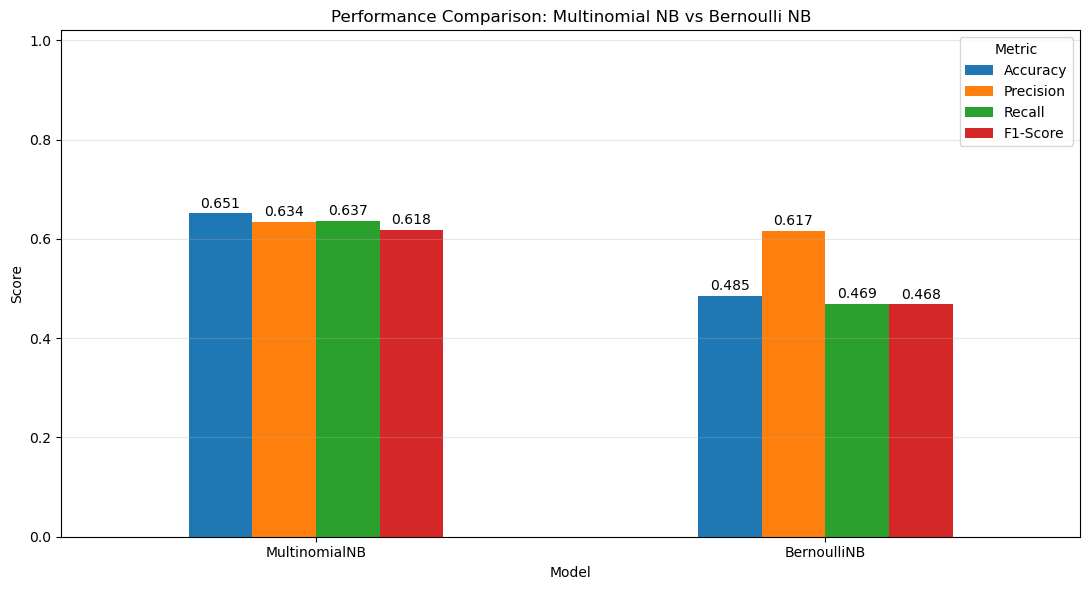

In [53]:
results_metrics=results[
    ["Model","Accuracy","Precision","Recall","F1-Score"]
]
ax=results_metrics.set_index("Model").plot(
    kind="bar",
    figsize=(11,6)
)
plt.title(
    "Performance Comparison: Multinomial NB vs Bernoulli NB" 
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1.02)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(
    axis="y",
    alpha=0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2
    )
plt.tight_layout()
plt.show()
